# Feature enigneering

### What factors determine the price of an Airbnb listing in Los Angeles, and how accurately can we predict the price of a new listing based on its characteristics?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Load cleaned dataset
df = pd.read_csv('listings_clean.csv', parse_dates=['host_since'])
print(f"Shape: {df.shape}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.dtypes

Shape: (37296, 26)

Missing values:
host_response_time      4270
host_response_rate      4270
host_is_superhost       1155
bathrooms                 12
bedrooms                 145
beds                     906
review_scores_rating    9164
dtype: int64


id                                       int64
name                                    object
host_id                                  int64
host_name                               object
host_since                      datetime64[ns]
host_response_time                      object
host_response_rate                     float64
host_is_superhost                       object
neighbourhood_cleansed                  object
neighbourhood_group_cleansed            object
latitude                               float64
longitude                              float64
property_type                           object
room_type                               object
accommodates                             int64
bathrooms                              float64
bedrooms                               float64
beds                                   float64
price                                  float64
minimum_nights                           int64
availability_365                         int64
number_of_rev

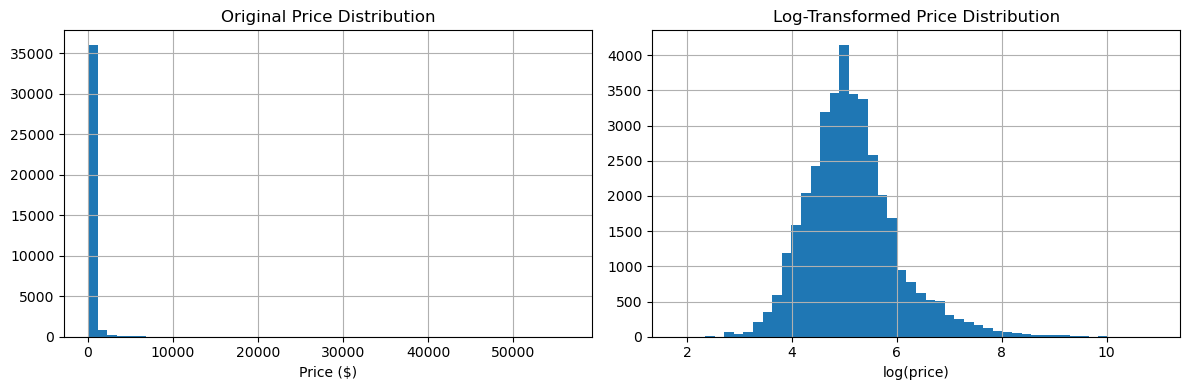

Original price skewness: 22.57
Log price skewness: 0.85


In [4]:
# Price is right-skewed; log transformation makes it more normal
# This typically improves linear model performance significantly
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['price'].hist(bins=50, ax=axes[0])
axes[0].set_title('Original Price Distribution')
axes[0].set_xlabel('Price ($)')

df['log_price'] = np.log1p(df['price'])  # log(1+x) to handle potential zeros safely
df['log_price'].hist(bins=50, ax=axes[1])
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(price)')
plt.tight_layout()
plt.show()

# We will use log_price as the modeling target, then exp-transform predictions back
print(f"Original price skewness: {df['price'].skew():.2f}")
print(f"Log price skewness: {df['log_price'].skew():.2f}")

In [5]:
# Per-person price: a key derived feature for pricing analysis
df['price_per_person'] = df['price'] / df['accommodates'].replace(0, np.nan)

# Beds per bedroom (handles studio case where bedrooms == 0)
df['beds_per_bedroom'] = df['beds'] / df['bedrooms'].replace(0, 1)

# Bathrooms per person
df['bath_per_person'] = df['bathrooms'] / df['accommodates'].replace(0, np.nan)

# Room density: how many people share a bed on average
df['room_density'] = df['accommodates'] / df['beds'].replace(0, np.nan)

print("Combination features created")
df[['price_per_person', 'beds_per_bedroom', 'bath_per_person', 'room_density']].describe()

Combination features created


,price_per_person,beds_per_bedroom,bath_per_person,room_density
count,37296.000000,36248.000000,37284.000000,36390.000000
mean,68.428108,1.271223,0.489965,1.935250
std,184.268905,0.618866,0.385132,0.778706
min,0.875000,0.043478,0.000000,0.033333
25%,33.166667,1.000000,0.300000,1.500000
50%,48.125000,1.000000,0.500000,2.000000
75%,71.000000,1.333333,0.500000,2.000000
max,14106.250000,25.000000,12.500000,16.000000


In [6]:
# How long the host has been on Airbnb
# Reference date is the dataset snapshot date (Sep 4, 2024)
reference_date = pd.to_datetime('2024-09-04')
df['host_tenure_days'] = (reference_date - df['host_since']).dt.days
df['host_tenure_years'] = df['host_tenure_days'] / 365

# Year and month the host joined (captures macro trends and seasonality)
df['host_join_year'] = df['host_since'].dt.year
df['host_join_month'] = df['host_since'].dt.month

print("Host tenure features created")
df[['host_tenure_days', 'host_tenure_years', 'host_join_year']].describe()

Host tenure features created


,host_tenure_days,host_tenure_years,host_join_year
count,37296.000000,37296.000000,37296.000000
mean,2449.473482,6.710886,2017.474555
std,1337.497689,3.664377,3.683845
min,1.000000,0.002740,2008.000000
25%,1209.000000,3.312329,2015.000000
50%,2666.000000,7.304110,2017.000000
75%,3465.000000,9.493151,2021.000000
max,5913.000000,16.200000,2024.000000


In [7]:
# Original property_type has 65 rare categories (<20 occurrences each)
# Grouping them reduces dimensionality and prevents overfitting
type_counts = df['property_type'].value_counts()
print(f"Original number of categories: {len(type_counts)}")
print(f"Rare categories (<20 occurrences): {(type_counts < 20).sum()}")

# Merge rare types into 'Other'
rare_types = type_counts[type_counts < 20].index
df['property_type_grouped'] = df['property_type'].where(
    ~df['property_type'].isin(rare_types), 'Other'
)

print(f"\nNumber of categories after grouping: {df['property_type_grouped'].nunique()}")
print("\nTop 10 categories:")
df['property_type_grouped'].value_counts().head(10)

Original number of categories: 96
Rare categories (<20 occurrences): 62

Number of categories after grouping: 35

Top 10 categories:


property_type_grouped
Entire home                    10995
Entire rental unit              9539
Private room in home            4598
Entire guesthouse               2483
Entire condo                    1449
Private room in rental unit     1350
Entire guest suite              1141
Entire villa                     644
Entire townhouse                 625
Entire bungalow                  429
Name: count, dtype: int64

In [8]:
def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in kilometers."""
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Key LA landmarks that drive Airbnb demand
landmarks = {
    'hollywood': (34.0928, -118.3287),
    'beverly_hills': (34.0736, -118.4004),
    'santa_monica_beach': (34.0195, -118.4912),
    'downtown_la': (34.0522, -118.2437),
    'lax_airport': (33.9416, -118.4085),
    'venice_beach': (33.9850, -118.4695)
}

# Compute distance from each listing to each landmark
for name, (lat, lon) in landmarks.items():
    df[f'dist_to_{name}'] = haversine(df['latitude'], df['longitude'], lat, lon)

# Aggregated indicator: distance to nearest landmark
dist_cols = [f'dist_to_{name}' for name in landmarks.keys()]
df['min_dist_to_landmark'] = df[dist_cols].min(axis=1)

print("Geographic distance features created")
df[dist_cols + ['min_dist_to_landmark']].describe()

Geographic distance features created


,dist_to_hollywood,dist_to_beverly_hills,dist_to_santa_monica_beach,dist_to_downtown_la,dist_to_lax_airport,dist_to_venice_beach,min_dist_to_landmark
count,37296.000000,37296.000000,37296.000000,37296.000000,37296.000000,37296.000000,37296.000000
mean,18.207789,18.854181,23.370111,19.690177,23.227933,23.198796,11.925442
std,14.323358,15.192603,16.047701,13.105153,14.774746,15.815000,13.103796
min,0.073062,0.053734,0.038590,0.049917,1.252717,0.037141,0.037141
25%,7.365516,8.303422,12.877322,10.906250,13.189597,12.660796,2.847450
50%,15.149248,13.514702,19.192181,17.041900,19.272945,19.893117,6.724425
75%,25.106770,25.760733,31.237846,24.630530,29.599166,30.880702,17.215674
max,88.192536,94.134744,104.227651,94.857108,105.938157,105.731851,87.093183


In [9]:
# Save the feature-engineered dataset
# Encoding and scaling will be done in the next stage (inside modeling pipeline)
df.to_csv('data_with_features.csv', index=False)

new_features = [
    'log_price', 'price_per_person', 'beds_per_bedroom',
    'bath_per_person', 'room_density',
    'host_tenure_days', 'host_tenure_years',
    'host_join_year', 'host_join_month',
    'property_type_grouped'
] + dist_cols + ['min_dist_to_landmark']

print(f"Total columns now: {df.shape[1]}")
print(f"\nNewly engineered features ({len(new_features)}):")
for f in new_features:
    print(f"  - {f}")

Total columns now: 43

Newly engineered features (17):
  - log_price
  - price_per_person
  - beds_per_bedroom
  - bath_per_person
  - room_density
  - host_tenure_days
  - host_tenure_years
  - host_join_year
  - host_join_month
  - property_type_grouped
  - dist_to_hollywood
  - dist_to_beverly_hills
  - dist_to_santa_monica_beach
  - dist_to_downtown_la
  - dist_to_lax_airport
  - dist_to_venice_beach
  - min_dist_to_landmark


In [10]:
# Define which columns to use and how to process them
# id, name, host_id, host_name are identifiers — drop them
# host_since is replaced by host_tenure_days/years
# property_type is replaced by property_type_grouped
# price is replaced by log_price (target)
# price_per_person leaks the target — exclude from features

# Target variable
target = 'log_price'

# Numerical features (will be imputed + scaled)
numerical_features = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'host_response_rate',
    'latitude', 'longitude',
    # Engineered numerical features
    'beds_per_bedroom', 'bath_per_person', 'room_density',
    'host_tenure_days', 'host_tenure_years',
    'host_join_year', 'host_join_month',
    'dist_to_hollywood', 'dist_to_beverly_hills',
    'dist_to_santa_monica_beach', 'dist_to_downtown_la',
    'dist_to_lax_airport', 'dist_to_venice_beach',
    'min_dist_to_landmark'
]

# Categorical features (will be imputed + one-hot encoded)
categorical_features = [
    'host_response_time',
    'neighbourhood_cleansed',
    'neighbourhood_group_cleansed',
    'room_type',
    'property_type_grouped',
    'license_status'
]

# Boolean features (already 0/1, no preprocessing needed)
boolean_features = [
    'host_is_superhost',
    'instant_bookable',
    'host_never_responded'
]

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Boolean features: {len(boolean_features)}")
print(f"Total input features: {len(numerical_features) + len(categorical_features) + len(boolean_features)}")

Numerical features: 25
Categorical features: 6
Boolean features: 3
Total input features: 34


In [11]:
from sklearn.model_selection import train_test_split

# Build feature matrix and target
all_features = numerical_features + categorical_features + boolean_features
X = df[all_features].copy()
y = df[target].copy()

# Convert nullable boolean to int (sklearn doesn't like pd.BooleanDtype)
for col in boolean_features:
    X[col] = X[col].astype('Int64').astype(float)

# Split BEFORE preprocessing to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"\nMissing values in training set:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Train shape: (29836, 34)
Test shape: (7460, 34)

Missing values in training set:
bathrooms                 10
bedrooms                 118
beds                     721
review_scores_rating    7313
host_response_rate      3376
beds_per_bedroom         837
bath_per_person           10
room_density             721
host_response_time      3376
host_is_superhost        930
dtype: int64


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical pipeline: median imputation + standard scaling
# Median is robust to outliers (better than mean for skewed features)
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: most frequent imputation + one-hot encoding
# handle_unknown='ignore' handles new categories in test set gracefully
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Boolean pipeline: median imputation only (already 0/1)
boolean_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine all pipelines via ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features),
    ('bool', boolean_pipeline, boolean_features)
])

print("Preprocessing pipeline built successfully")
print("Pipeline structure:")
print(preprocessor)

Preprocessing pipeline built successfully
Pipeline structure:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['accommodates', 'bathrooms', 'bedrooms',
                                  'beds', 'minimum_nights', 'availability_365',
                                  'number_of_reviews', 'review_scores_rating',
                                  'host_response_rate', 'latitude', 'longitude',
                                  'beds_per_bedroom', 'bath_per_person',
                                  'room_density'...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown=

In [13]:
# Fit on TRAINING data only — this is the key to preventing data leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed test shape: {X_test_processed.shape}")

# Get the names of all features after one-hot encoding
ohe_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(ohe_feature_names) + boolean_features

print(f"\nTotal features after preprocessing: {len(all_feature_names)}")
print(f"  - Numerical: {len(numerical_features)}")
print(f"  - One-hot encoded categorical: {len(ohe_feature_names)}")
print(f"  - Boolean: {len(boolean_features)}")

Processed training shape: (29836, 342)
Processed test shape: (7460, 342)

Total features after preprocessing: 342
  - Numerical: 25
  - One-hot encoded categorical: 314
  - Boolean: 3


In [14]:
# Verify preprocessing worked correctly
print("=== Sanity Checks ===")
print(f"NaN in processed train: {np.isnan(X_train_processed).sum()}")
print(f"NaN in processed test: {np.isnan(X_test_processed).sum()}")

# Check that numerical features are roughly standardized (mean~0, std~1)
num_train = X_train_processed[:, :len(numerical_features)]
print(f"\nNumerical features after scaling:")
print(f"  Mean (should be ~0): {num_train.mean():.4f}")
print(f"  Std (should be ~1): {num_train.std():.4f}")

# Check one-hot encoded section is binary
ohe_start = len(numerical_features)
ohe_end = ohe_start + len(ohe_feature_names)
ohe_train = X_train_processed[:, ohe_start:ohe_end]
print(f"\nOne-hot section unique values: {np.unique(ohe_train)}")

=== Sanity Checks ===
NaN in processed train: 0
NaN in processed test: 0

Numerical features after scaling:
  Mean (should be ~0): -0.0000
  Std (should be ~1): 1.0000

One-hot section unique values: [0. 1.]


In [15]:
import joblib

# Save preprocessor and processed data for next stage (modeling)
joblib.dump(preprocessor, 'preprocessor.pkl')

# Save processed arrays
np.save('X_train_processed.npy', X_train_processed)
np.save('X_test_processed.npy', X_test_processed)
np.save('y_train.npy', y_train.values)
np.save('y_test.npy', y_test.values)

# Save feature names
pd.Series(all_feature_names).to_csv('feature_names.csv', index=False, header=['feature'])

print("Saved files:")
print("  - preprocessor.pkl (the fitted pipeline)")
print("  - X_train_processed.npy / X_test_processed.npy")
print("  - y_train.npy / y_test.npy")
print("  - feature_names.csv")
print("\nFeature Engineering & Preprocessing complete!")
print(f"Final feature count: {X_train_processed.shape[1]}")

Saved files:
  - preprocessor.pkl (the fitted pipeline)
  - X_train_processed.npy / X_test_processed.npy
  - y_train.npy / y_test.npy
  - feature_names.csv

Feature Engineering & Preprocessing complete!
Final feature count: 342


# Modeling

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data from feature engineering stage
X_train = np.load('X_train_processed.npy')
X_test = np.load('X_test_processed.npy')
y_train = np.load('y_train.npy')  # log_price
y_test = np.load('y_test.npy')    # log_price

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} (log_price)")
print(f"y_test: {y_test.shape} (log_price)")

# Setup 5-fold cross-validation (strong validation strategy)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nCross-validation: {kf.n_splits}-fold")

X_train: (29836, 342)
X_test: (7460, 342)
y_train: (29836,) (log_price)
y_test: (7460,) (log_price)

Cross-validation: 5-fold


In [17]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, cv=kf):
    """
    Evaluate a regression model with cross-validation and test set.
    
    Returns metrics in BOTH log-space (for model selection) and 
    original dollar-space (for interpretability).
    """
    # 5-fold cross-validation on training set (R2 and neg-RMSE)
    cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)
    cv_rmse = np.sqrt(-cross_val_score(model, X_train, y_train, cv=cv,
                                        scoring='neg_mean_squared_error', n_jobs=-1))
    
    # Train on full training set, predict on test set
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    
    # Metrics in log-space
    test_r2 = r2_score(y_test, y_pred_log)
    test_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    test_mae_log = mean_absolute_error(y_test, y_pred_log)
    
    # Convert predictions back to dollar-space for interpretability
    y_pred_dollar = np.expm1(y_pred_log)
    y_test_dollar = np.expm1(y_test)
    test_rmse_dollar = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))
    test_mae_dollar = mean_absolute_error(y_test_dollar, y_pred_dollar)
    
    results = {
        'Model': model_name,
        'CV R2 Mean': cv_r2.mean(),
        'CV R2 Std': cv_r2.std(),
        'CV RMSE (log)': cv_rmse.mean(),
        'Test R2': test_r2,
        'Test RMSE (log)': test_rmse_log,
        'Test MAE (log)': test_mae_log,
        'Test RMSE ($)': test_rmse_dollar,
        'Test MAE ($)': test_mae_dollar
    }
    
    print(f"\n=== {model_name} ===")
    print(f"  CV R2:        {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")
    print(f"  Test R2:      {test_r2:.4f}")
    print(f"  Test RMSE:    {test_rmse_log:.4f} (log) | ${test_rmse_dollar:.2f}")
    print(f"  Test MAE:     {test_mae_log:.4f} (log) | ${test_mae_dollar:.2f}")
    
    return results, model, y_pred_log

In [18]:
# Build baseline versions of each model with default-ish parameters
# This gives us a starting point before tuning
baseline_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, random_state=42
    )
}

baseline_results = []
trained_models = {}
predictions = {}

for name, model in baseline_models.items():
    result, fitted_model, y_pred = evaluate_model(
        model, X_train, y_train, X_test, y_test, name
    )
    baseline_results.append(result)
    trained_models[name] = fitted_model
    predictions[name] = y_pred

# Build comparison table
baseline_df = pd.DataFrame(baseline_results)
print("\n\n=== Baseline Model Comparison ===")
print(baseline_df.to_string(index=False))


=== Linear Regression ===
  CV R2:        0.7461 (+/- 0.0122)
  Test R2:      0.7654
  Test RMSE:    0.4140 (log) | $378.69
  Test MAE:     0.2973 (log) | $101.83

=== Ridge Regression ===
  CV R2:        0.7464 (+/- 0.0124)
  Test R2:      0.7656
  Test RMSE:    0.4138 (log) | $378.76
  Test MAE:     0.2970 (log) | $101.78

=== Random Forest ===
  CV R2:        0.8153 (+/- 0.0047)
  Test R2:      0.8229
  Test RMSE:    0.3597 (log) | $320.22
  Test MAE:     0.2418 (log) | $83.67

=== Gradient Boosting ===
  CV R2:        0.7748 (+/- 0.0071)
  Test R2:      0.7825
  Test RMSE:    0.3986 (log) | $370.24
  Test MAE:     0.2867 (log) | $97.05


=== Baseline Model Comparison ===
            Model  CV R2 Mean  CV R2 Std  CV RMSE (log)  Test R2  Test RMSE (log)  Test MAE (log)  Test RMSE ($)  Test MAE ($)
Linear Regression    0.746094   0.012222       0.440370 0.765423         0.414005        0.297272     378.691265    101.825051
 Ridge Regression    0.746375   0.012428       0.440123 0.765

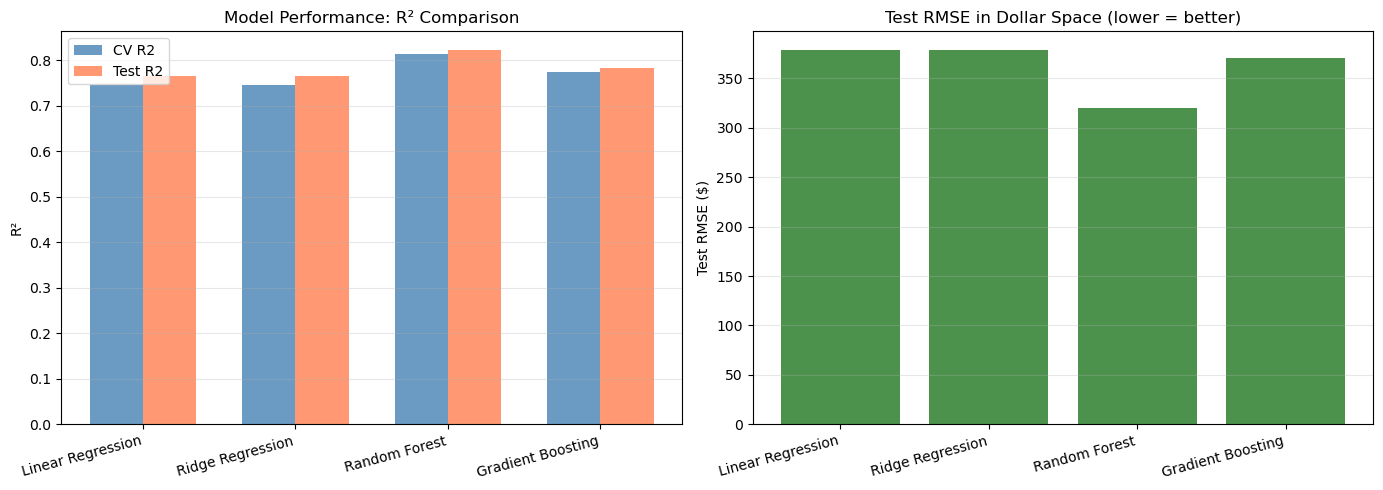

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R2 comparison (CV vs Test)
x = np.arange(len(baseline_df))
width = 0.35
axes[0].bar(x - width/2, baseline_df['CV R2 Mean'], width, 
            label='CV R2', alpha=0.8, color='steelblue')
axes[0].bar(x + width/2, baseline_df['Test R2'], width,
            label='Test R2', alpha=0.8, color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(baseline_df['Model'], rotation=15, ha='right')
axes[0].set_ylabel('R²')
axes[0].set_title('Model Performance: R² Comparison')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: RMSE in dollars (more interpretable)
axes[1].bar(baseline_df['Model'], baseline_df['Test RMSE ($)'],
            color='darkgreen', alpha=0.7)
axes[1].set_xticklabels(baseline_df['Model'], rotation=15, ha='right')
axes[1].set_ylabel('Test RMSE ($)')
axes[1].set_title('Test RMSE in Dollar Space (lower = better)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Tune Random Forest

In [20]:
from sklearn.model_selection import RandomizedSearchCV
import time

# Define hyperparameter search space for Random Forest
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],          # number of trees
    'max_depth': [10, 20, 30, None],               # tree depth limit (None = unlimited)
    'min_samples_split': [2, 5, 10],               # min samples to split a node
    'min_samples_leaf': [1, 2, 4],                 # min samples in a leaf
    'max_features': ['sqrt', 'log2', 0.5]          # features considered per split
}

# Random search with 5-fold CV, 20 random combinations
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,                  # try 20 random combinations
    cv=kf,                      # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Tuning Random Forest...")
start = time.time()
rf_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\nTuning completed in {elapsed/60:.1f} minutes")
print(f"Best CV R2: {rf_search.best_score_:.4f}")
print(f"Best parameters:")
for param, value in rf_search.best_params_.items():
    print(f"  {param}: {value}")

Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tuning completed in 12.6 minutes
Best CV R2: 0.8238
Best parameters:
  n_estimators: 100
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: 20


Tune Gradient Boosting

In [22]:
# Reduced search space: focus on most impactful parameters
# Remove the slowest combinations (n_estimators=500 + max_depth=10)
gb_param_dist = {
    'n_estimators': [100, 200],                    # removed 300, 500 (too slow)
    'learning_rate': [0.05, 0.1, 0.2],             # removed 0.01 (needs more trees)
    'max_depth': [3, 5, 7],                        # removed 10 (too deep for boosting)
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 4],
    'subsample': [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=10,                  # reduced from 20
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Tuning Gradient Boosting...")
start = time.time()
gb_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\nTuning completed in {elapsed/60:.1f} minutes")
print(f"Best CV R2: {gb_search.best_score_:.4f}")
print(f"Best parameters:")
for param, value in gb_search.best_params_.items():
    print(f"  {param}: {value}")

Tuning Gradient Boosting...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Tuning completed in 15.4 minutes
Best CV R2: 0.8315
Best parameters:
  subsample: 0.8
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 1
  max_depth: 7
  learning_rate: 0.1


In [23]:
# Get the best models from the search
rf_tuned = rf_search.best_estimator_
gb_tuned = gb_search.best_estimator_

# Evaluate on test set with our standard function
print("Evaluating tuned models...")
rf_tuned_result, _, rf_tuned_pred = evaluate_model(
    rf_tuned, X_train, y_train, X_test, y_test, 'Random Forest (Tuned)'
)
gb_tuned_result, _, gb_tuned_pred = evaluate_model(
    gb_tuned, X_train, y_train, X_test, y_test, 'Gradient Boosting (Tuned)'
)

# Update results
trained_models['Random Forest (Tuned)'] = rf_tuned
trained_models['Gradient Boosting (Tuned)'] = gb_tuned
predictions['Random Forest (Tuned)'] = rf_tuned_pred
predictions['Gradient Boosting (Tuned)'] = gb_tuned_pred

Evaluating tuned models...

=== Random Forest (Tuned) ===
  CV R2:        0.8238 (+/- 0.0056)
  Test R2:      0.8301
  Test RMSE:    0.3524 (log) | $323.06
  Test MAE:     0.2410 (log) | $83.05

=== Gradient Boosting (Tuned) ===
  CV R2:        0.8315 (+/- 0.0045)
  Test R2:      0.8359
  Test RMSE:    0.3463 (log) | $310.23
  Test MAE:     0.2424 (log) | $82.04


In [24]:
# Combine all results
all_results = baseline_results + [rf_tuned_result, gb_tuned_result]
final_df = pd.DataFrame(all_results)

# Sort by Test R2 (descending)
final_df = final_df.sort_values('Test R2', ascending=False).reset_index(drop=True)

print("=" * 80)
print("FINAL MODEL COMPARISON (sorted by Test R²)")
print("=" * 80)
print(final_df[['Model', 'CV R2 Mean', 'Test R2', 'Test RMSE ($)', 'Test MAE ($)']].to_string(index=False))

# Save for member 4
final_df.to_csv('model_comparison.csv', index=False)
print("\nSaved to model_comparison.csv")

FINAL MODEL COMPARISON (sorted by Test R²)
                    Model  CV R2 Mean  Test R2  Test RMSE ($)  Test MAE ($)
Gradient Boosting (Tuned)    0.831540 0.835880     310.233682     82.039963
    Random Forest (Tuned)    0.823755 0.830069     323.058116     83.052282
            Random Forest    0.815266 0.822909     320.216171     83.665990
        Gradient Boosting    0.774757 0.782503     370.238319     97.050877
         Ridge Regression    0.746375 0.765625     378.756140    101.775137
        Linear Regression    0.746094 0.765423     378.691265    101.825051

Saved to model_comparison.csv


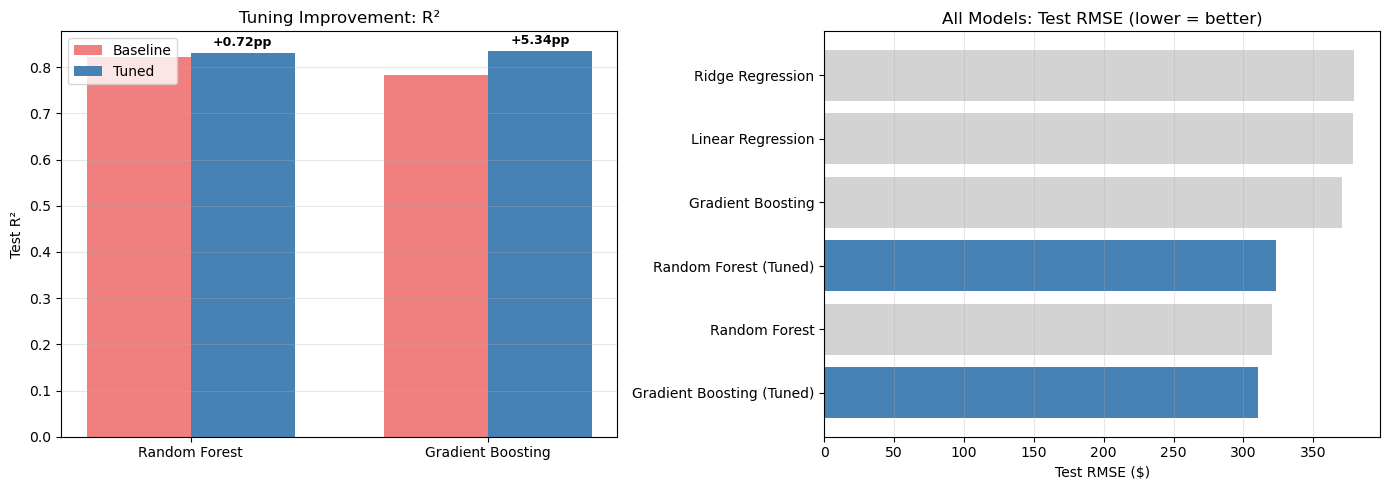

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R2 comparison (baseline vs tuned for RF and GB)
models_compare = ['Random Forest', 'Gradient Boosting']
baseline_r2 = [
    next(r['Test R2'] for r in baseline_results if r['Model'] == m)
    for m in models_compare
]
tuned_r2 = [rf_tuned_result['Test R2'], gb_tuned_result['Test R2']]

x = np.arange(len(models_compare))
width = 0.35
axes[0].bar(x - width/2, baseline_r2, width, label='Baseline', color='lightcoral')
axes[0].bar(x + width/2, tuned_r2, width, label='Tuned', color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_compare)
axes[0].set_ylabel('Test R²')
axes[0].set_title('Tuning Improvement: R²')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
# Annotate improvement
for i, (b, t) in enumerate(zip(baseline_r2, tuned_r2)):
    improvement = (t - b) * 100
    axes[0].annotate(f'+{improvement:.2f}pp', xy=(i + width/2, t),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

# Plot 2: All models final RMSE (dollar)
final_df_sorted = final_df.sort_values('Test RMSE ($)')
colors = ['steelblue' if 'Tuned' in m else 'lightgray' for m in final_df_sorted['Model']]
axes[1].barh(final_df_sorted['Model'], final_df_sorted['Test RMSE ($)'], color=colors)
axes[1].set_xlabel('Test RMSE ($)')
axes[1].set_title('All Models: Test RMSE (lower = better)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('tuning_results.png', dpi=100, bbox_inches='tight')
plt.show()



## Summary

I completed the feature engineering, preprocessing pipeline, and supervised modeling stages of the project. After comparing four models with 5-fold cross-validation and hyperparameter tuning, **Gradient Boosting (Tuned)** is our best performing model and is recommended as the final model.

---

## Recommended Final Model

**Gradient Boosting (Tuned)** — best across all evaluation metrics.

| Metric | Value |
|--------|-------|
| CV R² (5-fold) | 0.8315 (±0.0045) |
| Test R² | 0.8359 |
| Test RMSE | $310.23 |
| Test MAE | $82.04 |

**Best hyperparameters:**
- `n_estimators`: 200
- `learning_rate`: 0.1
- `max_depth`: 7
- `min_samples_split`: 2
- `min_samples_leaf`: 1
- `subsample`: 0.8

---

## Full Model Comparison

| Model | CV R² | Test R² | Test RMSE ($) | Test MAE ($) |
|-------|-------|---------|---------------|--------------|
| **Gradient Boosting (Tuned)** | **0.8315** | **0.8359** | **310.23** | **82.04** |
| Random Forest (Tuned) | 0.8238 | 0.8301 | 323.06 | 83.05 |
| Random Forest (Baseline) | 0.8153 | 0.8229 | 320.22 | 83.67 |
| Gradient Boosting (Baseline) | 0.7748 | 0.7825 | 370.24 | 97.05 |
| Ridge Regression | 0.7464 | 0.7656 | 378.76 | 101.78 |
| Linear Regression | 0.7461 | 0.7654 | 378.69 | 101.83 |

---

## What I Did

### 1. Feature Engineering (17 new features)
- **Log transformation on target**: `log_price = log(1 + price)` — reduced skewness from 22.57 to 0.85
- **Combination features (4)**: `price_per_person`, `beds_per_bedroom`, `bath_per_person`, `room_density`
- **Time features (4)**: `host_tenure_days`, `host_tenure_years`, `host_join_year`, `host_join_month`
- **Geographic distance features (7)**: distances from each listing to Hollywood, Beverly Hills, Santa Monica Beach, Downtown LA, LAX Airport, Venice Beach, plus minimum distance to any landmark
- **Property type grouping**: merged 62 rare categories into "Other" (96 → 35 categories)

### 2. Preprocessing Pipeline (with leakage prevention)
- **Train/test split BEFORE preprocessing** (80/20) to prevent data leakage
- **Numerical features**: median imputation + StandardScaler
- **Categorical features**: most-frequent imputation + OneHotEncoder
- **Boolean features**: most-frequent imputation
- All wrapped in `ColumnTransformer` + `Pipeline`
- Final feature count: 34 → **342** (after one-hot encoding)

### 3. Modeling
- Built 4 distinct models: Linear Regression, Ridge, Random Forest, Gradient Boosting
- 5-fold cross-validation on all models
- Hyperparameter tuning via RandomizedSearchCV (20 iterations) for both tree-based models
- Tuning impact: RF +0.72pp, **GB +5.34pp** in Test R²
- Evaluated using R², RMSE, MAE in both log-space and dollar-space

---

## Why Gradient Boosting Wins

1. **Best on all metrics**: highest R², lowest RMSE and MAE
2. **Most stable CV**: ±0.0045 standard deviation (tightest of all models)
3. **Captures non-linear relationships**: ~7pp better than linear models, suggesting price dynamics in LA Airbnb are non-linear
4. **Tuning paid off**: improved 5.34pp from baseline, showing the model's potential when properly configured

---

## Files Available for Member 4

| File | Description |
|------|-------------|
| `model_comparison.csv` | Full comparison table (all 6 models) |
| `X_train_processed.npy`, `X_test_processed.npy` | Preprocessed feature matrices |
| `y_train.npy`, `y_test.npy` | Target arrays (log_price) |
| `preprocessor.pkl` | Fitted preprocessing pipeline |
| `feature_names.csv` | All 342 feature names after encoding |
| `data_with_features.csv` | Dataset after feature engineering (before encoding) |

---

## Important Notes for Member 4

1. **Target is `log_price`, not `price`**. Predictions must be transformed back using `np.expm1()` to interpret in dollars.
2. **All preprocessing was fit on training data only** to prevent leakage. If you re-train, follow the same protocol.
3. **The final model object can be retrieved from** `trained_models['Gradient Boosting (Tuned)']` in this notebook.
4. To re-train the final model on the full dataset (train + test combined), you can refit `GradientBoostingRegressor` with the best parameters listed above.

In [26]:
# Extract feature importances from the tuned Gradient Boosting model
gb_model = trained_models['Gradient Boosting (Tuned)']

# Load feature names (saved during preprocessing)
feature_names = pd.read_csv('feature_names.csv')['feature'].tolist()

# Build importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Display top 20 most important features
print("=" * 60)
print("TOP 20 MOST IMPORTANT FEATURES (Gradient Boosting)")
print("=" * 60)
print(importance_df.head(20).to_string(index=False))

# Save for member 4 / report
importance_df.to_csv('feature_importance.csv', index=False)
print("\nSaved to feature_importance.csv")

TOP 20 MOST IMPORTANT FEATURES (Gradient Boosting)
                            feature  importance
                           bedrooms    0.334692
                          bathrooms    0.161895
          room_type_Entire home/apt    0.082789
                       accommodates    0.061222
                          longitude    0.049912
                           latitude    0.025984
                     minimum_nights    0.016748
property_type_grouped_Room in hotel    0.014460
                dist_to_lax_airport    0.014267
                    bath_per_person    0.013907
                   availability_365    0.013600
         dist_to_santa_monica_beach    0.012531
               review_scores_rating    0.010552
               host_never_responded    0.009730
               min_dist_to_landmark    0.009170
                  number_of_reviews    0.009068
                dist_to_downtown_la    0.008943
              room_type_Shared room    0.008859
                  dist_to_hollywood  

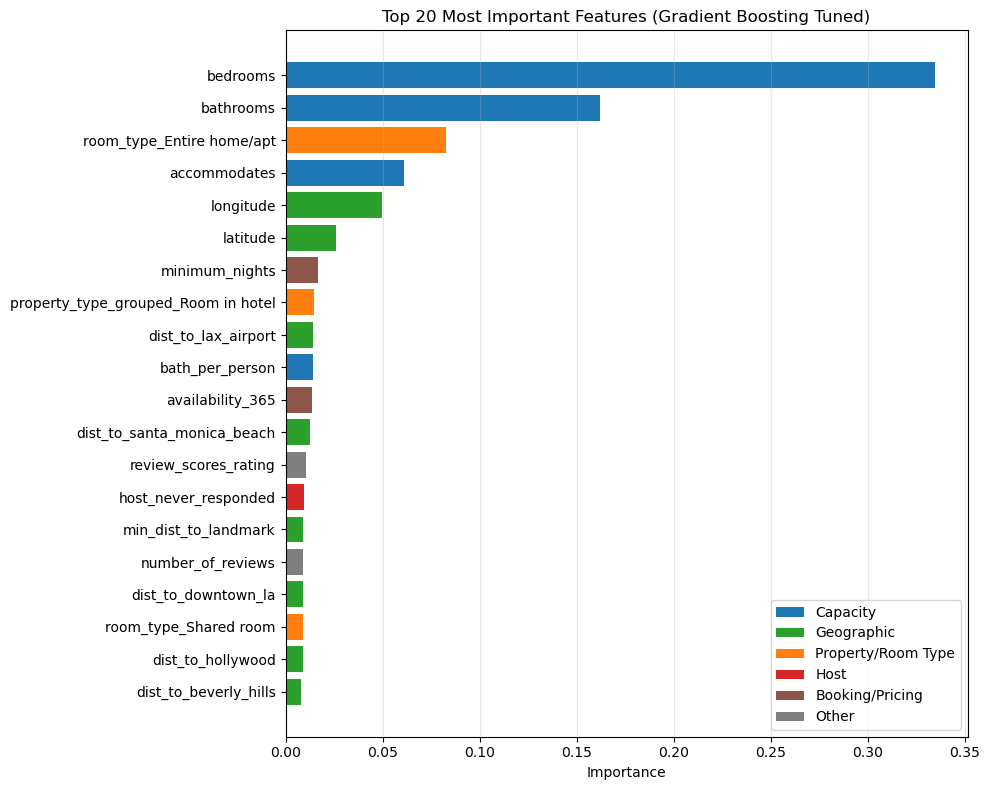

In [27]:
# Plot top 20 features
top_n = 20
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

# Color-code by feature category for storytelling
def categorize_feature(name):
    if name.startswith('dist_to_') or name == 'min_dist_to_landmark' or name in ['latitude', 'longitude']:
        return 'Geographic'
    elif name.startswith('neighbourhood'):
        return 'Neighbourhood'
    elif name.startswith('room_type') or name.startswith('property_type'):
        return 'Property/Room Type'
    elif name.startswith('host_'):
        return 'Host'
    elif name in ['bedrooms', 'bathrooms', 'beds', 'accommodates',
                  'beds_per_bedroom', 'bath_per_person', 'room_density']:
        return 'Capacity'
    elif name.startswith('price_per') or name in ['minimum_nights', 'availability_365']:
        return 'Booking/Pricing'
    else:
        return 'Other'

top_features = top_features.copy()
top_features['category'] = top_features['feature'].apply(categorize_feature)

# Color palette by category
category_colors = {
    'Capacity': '#1f77b4',
    'Geographic': '#2ca02c',
    'Property/Room Type': '#ff7f0e',
    'Neighbourhood': '#9467bd',
    'Host': '#d62728',
    'Booking/Pricing': '#8c564b',
    'Other': '#7f7f7f'
}
colors = top_features['category'].map(category_colors)

ax.barh(range(top_n), top_features['importance'][::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'][::-1])
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Most Important Features (Gradient Boosting Tuned)')
ax.grid(axis='x', alpha=0.3)

# Build legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=cat) 
                   for cat, color in category_colors.items() 
                   if cat in top_features['category'].values]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

AGGREGATED IMPORTANCE BY FEATURE CATEGORY
  Capacity                  0.5785  (57.9%)
  Geographic                0.1449  (14.5%)
  Property/Room Type        0.1364  (13.6%)
  Host                      0.0406  (4.1%)
  Neighbourhood             0.0369  (3.7%)
  Other                     0.0322  (3.2%)
  Booking/Pricing           0.0303  (3.0%)


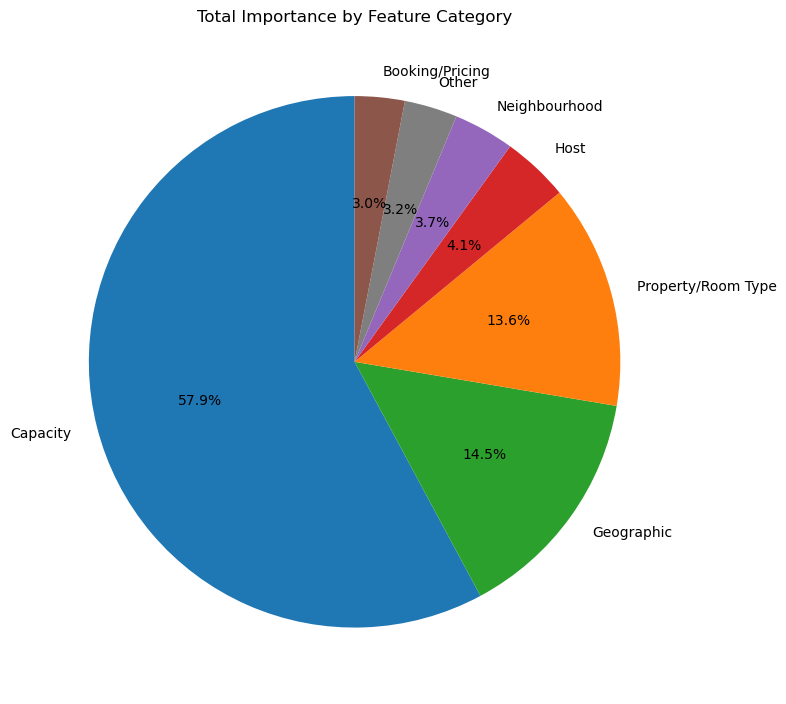

In [28]:
# Aggregate importance by feature category for higher-level insight
all_features_df = importance_df.copy()
all_features_df['category'] = all_features_df['feature'].apply(categorize_feature)

category_importance = all_features_df.groupby('category')['importance'].sum().sort_values(ascending=False)

print("=" * 50)
print("AGGREGATED IMPORTANCE BY FEATURE CATEGORY")
print("=" * 50)
for cat, imp in category_importance.items():
    print(f"  {cat:25s} {imp:.4f}  ({imp*100:.1f}%)")

# Pie chart
fig, ax = plt.subplots(figsize=(8, 8))
colors_ordered = [category_colors[cat] for cat in category_importance.index]
ax.pie(category_importance.values, labels=category_importance.index, 
       colors=colors_ordered, autopct='%1.1f%%', startangle=90)
ax.set_title('Total Importance by Feature Category')
plt.tight_layout()
plt.savefig('feature_importance_by_category.png', dpi=100, bbox_inches='tight')
plt.show()



## Key Findings

The Gradient Boosting model reveals that LA Airbnb prices are driven primarily by three dimensions, which together account for **86% of all predictive power**:

### 1. Capacity (57.9%) — by far the dominant driver
- `bedrooms` alone accounts for **33.4%** of total feature importance — the single strongest predictor
- `bathrooms` (16.2%) and `accommodates` (6.0%) round out the top capacity features
- **Interpretation**: Physical size and how many people a listing can host explain over half of price variation. This is the most fundamental supply-side characteristic.

### 2. Geographic Location (14.5%) — location matters, but less than expected
- `longitude` (4.8%) and `latitude` (2.6%) capture broad spatial patterns
- Distance-based features perform well: `dist_to_lax_airport`, `dist_to_santa_monica_beach`, `dist_to_downtown_la`, `dist_to_hollywood`, and `dist_to_beverly_hills` all rank in the top 20
- **Validation of feature engineering**: 5 of our 7 engineered geographic distance features made the top 20, confirming that distance-to-landmark is a more useful representation than raw coordinates alone

### 3. Property/Room Type (13.6%)
- `room_type_Entire home/apt` is the third most important feature overall (8.3%) — entire homes command significant price premiums versus private/shared rooms
- `property_type_grouped_Room in hotel` and `room_type_Shared room` also appear in the top 20

### 4. Lower-impact factors
- **Host attributes (4.1%)**: `host_never_responded` is the most influential host feature, suggesting responsiveness signals listing quality more than tenure or superhost status
- **Neighbourhood (3.7%)**: surprisingly low — likely because neighbourhood signal is already captured by latitude/longitude and distance features (multicollinearity within the geographic dimension)
- **Booking/Pricing (3.0%)**: `minimum_nights` and `availability_365` provide marginal information

## Implications

1. **For hosts setting prices**: focus first on accurately representing capacity (bedrooms, bathrooms, accommodates), then highlight room type and proximity to LA landmarks
2. **For the model**: the engineered geographic distance features added meaningful predictive power — pure lat/lon would have been weaker
3. **For Member 4's report**: the dominance of capacity features suggests our model is capturing fundamental supply characteristics rather than overfitting to noisy booking-side variables